### Import Libraries

We import necessary libraries for data manipulation, preprocessing, modeling, evaluation, and explainability, including pandas, scikit-learn, matplotlib, seaborn, and SHAP.


In [1]:
!pip install catboost

  Using cached catboost-1.2.8-cp311-cp311-manylinux2014_x86_64.whl.metadata (1.2 kB)
Using cached catboost-1.2.8-cp311-cp311-manylinux2014_x86_64.whl (99.2 MB)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

### Load Dataset

We load the customer dataset containing financial, demographic, and behavioral features, which we will use to classify credit scores into Bad, Standard, or Good categories.


In [3]:
df = pd.read_csv('/content/Bank Data.csv')

In [4]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3.0,...,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3.0,...,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3.0,...,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24_,821-00-0265,Scientist,19114.12,NaN,3.0,...,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,0x1616,CUS_0x21b1,September,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2.0,...,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923


### Data Preprocessing

We apply preprocessing steps:
- Drop non-informative columns (e.g., ID, Customer_ID, Name, SSN)
- Handle missing values:
    - Fill numerical with median
    - Fill categorical with mode or "Unknown"
- Encode categorical variables:
    - Label encode ordinal features (Payment_Behaviour, Credit_Mix, Occupation)
    - One-hot encode multi-label features (Type_of_Loan)
- Cap outliers using the IQR method
- Encode target: Bad = 0, Standard = 1, Good = 2


### Exploratory Data Analysis (EDA)

We explore the dataset to understand distributions and relationships:
- Check class distribution (Credit_Mix: Standard, Good, Bad)
- Visualize important features with count plots, box plots, and heatmaps
- Identify top features using feature importance and SHAP


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13685 entries, 0 to 13684
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        13685 non-null  object 
 1   Customer_ID               13685 non-null  object 
 2   Month                     13684 non-null  object 
 3   Name                      12257 non-null  object 
 4   Age                       13684 non-null  object 
 5   SSN                       13684 non-null  object 
 6   Occupation                13684 non-null  object 
 7   Annual_Income             13684 non-null  object 
 8   Monthly_Inhand_Salary     11622 non-null  float64
 9   Num_Bank_Accounts         13684 non-null  float64
 10  Num_Credit_Card           13684 non-null  float64
 11  Interest_Rate             13684 non-null  float64
 12  Num_of_Loan               13684 non-null  object 
 13  Type_of_Loan              12096 non-null  object 
 14  Delay_

In [6]:
df.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,11622.000000,13684.000000,13684.000000,13684.000000,13684.000000,13398.000000,13684.000000,13684.000000
mean,4268.421084,16.162672,23.713315,65.859836,20.944315,32.675698,32.257224,1478.366736
std,3226.322375,111.236393,131.924455,437.410829,14.619822,208.072727,5.101085,8542.801982
min,333.596667,0.000000,0.000000,1.000000,-5.000000,0.000000,20.509652,0.000000
25%,1650.781667,3.000000,4.000000,7.000000,10.000000,4.000000,28.053177,31.779454
50%,3143.796667,6.000000,6.000000,13.000000,18.000000,7.000000,32.249585,74.869250
75%,6098.132083,7.000000,7.000000,20.000000,28.000000,10.000000,36.405840,179.280882
max,14866.446667,1769.000000,1499.000000,5799.000000,67.000000,2593.000000,48.540663,82347.000000


In [7]:
df.shape

(13685, 27)

In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
df.isnull().sum()

,0
ID,0
Customer_ID,0
Month,1
Name,1428
Age,1
SSN,1
Occupation,1
Annual_Income,1
Monthly_Inhand_Salary,2063
Num_Bank_Accounts,1


In [10]:
df['Credit_Mix'].unique()
df['Credit_Mix'].value_counts()


,count
Credit_Mix,
Standard,4931
Good,3391
_,2780
Bad,2582


In [11]:
df['Credit_Mix'].unique()

array(['Good', '_', 'Standard', 'Bad', nan], dtype=object)

In [12]:
df['Payment_Behaviour'].unique()
df['Payment_of_Min_Amount'].unique()


array(['No', 'Yes', 'NM', nan], dtype=object)

In [13]:
df['Payment_Behaviour'].unique()


array(['Low_spent_Small_value_payments',
       'High_spent_Medium_value_payments',
       'Low_spent_Medium_value_payments',
       'High_spent_Large_value_payments',
       'Low_spent_Large_value_payments', '!@9#%8',
       'High_spent_Small_value_payments', nan], dtype=object)

In [14]:
columns_to_drop = ['ID', 'Customer_ID', 'Name', 'SSN', 'Month']
df.drop(columns=columns_to_drop, inplace=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13685 entries, 0 to 13684
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       13684 non-null  object 
 1   Occupation                13684 non-null  object 
 2   Annual_Income             13684 non-null  object 
 3   Monthly_Inhand_Salary     11622 non-null  float64
 4   Num_Bank_Accounts         13684 non-null  float64
 5   Num_Credit_Card           13684 non-null  float64
 6   Interest_Rate             13684 non-null  float64
 7   Num_of_Loan               13684 non-null  object 
 8   Type_of_Loan              12096 non-null  object 
 9   Delay_from_due_date       13684 non-null  float64
 10  Num_of_Delayed_Payment    12709 non-null  object 
 11  Changed_Credit_Limit      13684 non-null  object 
 12  Num_Credit_Inquiries      13398 non-null  float64
 13  Credit_Mix                13684 non-null  object 
 14  Outsta

In [16]:
mode_value = df.loc[df['Credit_Mix'] != '_', 'Credit_Mix'].mode()[0]
df['Credit_Mix'] = df['Credit_Mix'].replace('_', mode_value)


<Axes: xlabel='Credit_Mix', ylabel='count'>

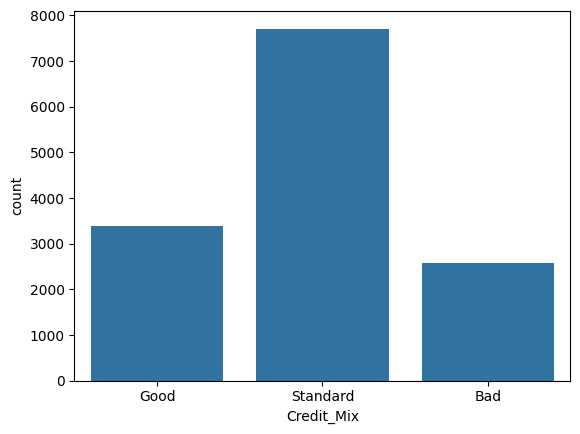

In [17]:
df['Credit_Mix'].value_counts()
sns.countplot(x='Credit_Mix', data=df)


In [18]:
df.head()

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,23,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,...,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,24,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,...,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,24,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1.0,...,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,24_,Scientist,19114.12,NaN,3.0,4.0,3.0,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",4.0,...,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,28,_______,34847.84,3037.986667,2.0,4.0,6.0,1,Credit-Builder Loan,3.0,...,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923


In [19]:
def clean_numeric(col):
    return pd.to_numeric(df[col].astype(str).str.replace(',', '').str.strip(), errors='coerce')

numeric_columns = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
                   'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance']

for col in numeric_columns:
    df[col] = clean_numeric(col)


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13685 entries, 0 to 13684
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       12978 non-null  float64
 1   Occupation                13684 non-null  object 
 2   Annual_Income             12692 non-null  float64
 3   Monthly_Inhand_Salary     11622 non-null  float64
 4   Num_Bank_Accounts         13684 non-null  float64
 5   Num_Credit_Card           13684 non-null  float64
 6   Interest_Rate             13684 non-null  float64
 7   Num_of_Loan               13008 non-null  float64
 8   Type_of_Loan              12096 non-null  object 
 9   Delay_from_due_date       13684 non-null  float64
 10  Num_of_Delayed_Payment    12315 non-null  float64
 11  Changed_Credit_Limit      13393 non-null  float64
 12  Num_Credit_Inquiries      13398 non-null  float64
 13  Credit_Mix                13684 non-null  object 
 14  Outsta

In [21]:
df['Payment_of_Min_Amount'].unique()

array(['No', 'Yes', 'NM', nan], dtype=object)

In [22]:
df['Payment_Behaviour'].unique()

array(['Low_spent_Small_value_payments',
       'High_spent_Medium_value_payments',
       'Low_spent_Medium_value_payments',
       'High_spent_Large_value_payments',
       'Low_spent_Large_value_payments', '!@9#%8',
       'High_spent_Small_value_payments', nan], dtype=object)

In [23]:
df['Type_of_Loan'].unique()

array(['Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan',
       'Credit-Builder Loan', 'Auto Loan, Auto Loan, and Not Specified',
       ...,
       'Debt Consolidation Loan, Payday Loan, Auto Loan, Mortgage Loan, and Not Specified',
       'Credit-Builder Loan, Personal Loan, Student Loan, and Credit-Builder Loan',
       'Payday Loan, Home Equity Loan, Auto Loan, Mortgage Loan, and Credit-Builder Loan'],
      dtype=object)

In [24]:
df['Occupation'].unique()

array(['Scientist', '_______', 'Teacher', 'Engineer', 'Entrepreneur',
       'Developer', 'Lawyer', 'Media_Manager', 'Doctor', 'Journalist',
       'Manager', 'Accountant', 'Musician', 'Mechanic', 'Writer',
       'Architect', nan], dtype=object)

In [25]:
df.isnull().sum()

,0
Age,707
Occupation,1
Annual_Income,993
Monthly_Inhand_Salary,2063
Num_Bank_Accounts,1
Num_Credit_Card,1
Interest_Rate,1
Num_of_Loan,677
Type_of_Loan,1589
Delay_from_due_date,1


In [26]:
num_cols = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
            'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt',
            'Amount_invested_monthly', 'Monthly_Balance']

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

<ipython-input-26-a1c4464ff7eb>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [27]:
df[['Annual_Income', 'Monthly_Inhand_Salary']].corr()


,Annual_Income,Monthly_Inhand_Salary
Annual_Income,1.000000,0.028903
Monthly_Inhand_Salary,0.028903,1.000000


In [28]:
median_salary = df['Monthly_Inhand_Salary'].median()
df['Monthly_Inhand_Salary'].fillna(median_salary, inplace=True)


<ipython-input-28-8a64ee51e364>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Monthly_Inhand_Salary'].fillna(median_salary, inplace=True)


In [29]:
import numpy as np


def convert_credit_history(x):
    try:
        years, months = 0, 0
        if 'Years' in x:
            years = int(x.split('Years')[0].strip())
            if 'Months' in x:
                months = int(x.split('Years')[1].split('Months')[0].strip())
        elif 'Months' in x:
            months = int(x.split('Months')[0].strip())
        return years * 12 + months
    except:
        return np.nan


df['Credit_History_Age'] = df['Credit_History_Age'].astype(str).apply(convert_credit_history)


median_value = df['Credit_History_Age'].median()
df['Credit_History_Age'].fillna(median_value, inplace=True)


<ipython-input-29-4d1e3f319aa3>:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Credit_History_Age'].fillna(median_value, inplace=True)


In [30]:
df['Occupation'].value_counts()


,count
Occupation,
_______,963
Mechanic,905
Lawyer,899
Teacher,884
Developer,882
Media_Manager,876
Journalist,876
Architect,874
Writer,846


In [31]:
df['Occupation'] = df['Occupation'].replace('_______', 'Unknown')
df['Occupation_missing'] = df['Occupation'].apply(lambda x: 1 if x == 'Unknown' else 0)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Occupation'] = le.fit_transform(df['Occupation'])

print(dict(zip(le.classes_, le.transform(le.classes_))))


{'Accountant': np.int64(0), 'Architect': np.int64(1), 'Developer': np.int64(2), 'Doctor': np.int64(3), 'Engineer': np.int64(4), 'Entrepreneur': np.int64(5), 'Journalist': np.int64(6), 'Lawyer': np.int64(7), 'Manager': np.int64(8), 'Mechanic': np.int64(9), 'Media_Manager': np.int64(10), 'Musician': np.int64(11), 'Scientist': np.int64(12), 'Teacher': np.int64(13), 'Unknown': np.int64(14), 'Writer': np.int64(15), nan: np.int64(16)}


In [32]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Payment_of_Min_Amount'] = le.fit_transform(df['Payment_of_Min_Amount'])


In [33]:
mode_pb = df['Payment_Behaviour'].mode()[0]
df['Payment_Behaviour'].replace('!@#%8', mode_pb, inplace=True)

mapping = {
    'Low_spent_Small_value_payments': 0,
    'Low_spent_Medium_value_payments': 1,
    'Low_spent_Large_value_payments': 2,
    'High_spent_Small_value_payments': 3,
    'High_spent_Medium_value_payments': 4,
    'High_spent_Large_value_payments': 5
}

df['Payment_Behaviour'] = df['Payment_Behaviour'].map(mapping)

mode_value = df['Payment_Behaviour'].mode()[0]
df['Payment_Behaviour'].fillna(mode_value, inplace=True)


<ipython-input-33-38990cd0d8d8>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Payment_Behaviour'].replace('!@#%8', mode_pb, inplace=True)
<ipython-input-33-38990cd0d8d8>:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

In [34]:
all_loans = set()
for row in df['Type_of_Loan'].dropna():
    loans = [loan.strip() for loan in row.split(',')]
    all_loans.update(loans)

loan_types_df = pd.DataFrame(sorted(all_loans), columns=['Loan_Type'])

print(loan_types_df)

                      Loan_Type
0                     Auto Loan
1           Credit-Builder Loan
2       Debt Consolidation Loan
3              Home Equity Loan
4                 Mortgage Loan
5                 Not Specified
6                   Payday Loan
7                 Personal Loan
8                  Student Loan
9                 and Auto Loan
10      and Credit-Builder Loan
11  and Debt Consolidation Loan
12         and Home Equity Loan
13            and Mortgage Loan
14            and Not Specified
15              and Payday Loan
16            and Personal Loan
17             and Student Loan


In [35]:
df['Type_of_Loan'] = df['Type_of_Loan'].str.replace(', and', ',', regex=False)

df['Type_of_Loan'] = df['Type_of_Loan'].str.replace('and ', '', regex=False)


In [36]:
all_loans = set()
for row in df['Type_of_Loan'].dropna():
    loans = [loan.strip() for loan in row.split(',')]
    all_loans.update(loans)

loan_types_df = pd.DataFrame(sorted(all_loans), columns=['Loan_Type'])

print(loan_types_df)

                 Loan_Type
0                Auto Loan
1      Credit-Builder Loan
2  Debt Consolidation Loan
3         Home Equity Loan
4            Mortgage Loan
5            Not Specified
6              Payday Loan
7            Personal Loan
8             Student Loan


In [37]:
df['Type_of_Loan'] = df['Type_of_Loan'].fillna('Not Specified')
df['Type_of_Loan'] = df['Type_of_Loan'].apply(
    lambda x: ', '.join(sorted(set([i.strip() for i in x.split(',')])))
)


In [38]:
all_loans = set()
for row in df['Type_of_Loan']:
    loans = [loan.strip() for loan in row.split(',')]
    all_loans.update(loans)
all_loans = sorted(all_loans)
print(all_loans)


['Auto Loan', 'Credit-Builder Loan', 'Debt Consolidation Loan', 'Home Equity Loan', 'Mortgage Loan', 'Not Specified', 'Payday Loan', 'Personal Loan', 'Student Loan']


In [39]:
for loan in all_loans:
    df[loan] = df['Type_of_Loan'].apply(lambda x: 1 if loan in x else 0)
df.drop(columns=['Type_of_Loan'], inplace=True)


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13685 entries, 0 to 13684
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       13685 non-null  float64
 1   Occupation                13685 non-null  int64  
 2   Annual_Income             13685 non-null  float64
 3   Monthly_Inhand_Salary     13685 non-null  float64
 4   Num_Bank_Accounts         13684 non-null  float64
 5   Num_Credit_Card           13684 non-null  float64
 6   Interest_Rate             13684 non-null  float64
 7   Num_of_Loan               13685 non-null  float64
 8   Delay_from_due_date       13684 non-null  float64
 9   Num_of_Delayed_Payment    13685 non-null  float64
 10  Changed_Credit_Limit      13685 non-null  float64
 11  Num_Credit_Inquiries      13685 non-null  float64
 12  Credit_Mix                13684 non-null  object 
 13  Outstanding_Debt          13685 non-null  float64
 14  Credit

In [41]:
df.isnull().sum()

,0
Age,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,1
Num_Credit_Card,1
Interest_Rate,1
Num_of_Loan,0
Delay_from_due_date,1
Num_of_Delayed_Payment,0


In [42]:
mapping = {'Bad': 0, 'Standard': 1, 'Good': 2}
df['Credit_Mix'] = df['Credit_Mix'].map(mapping)


In [43]:
print(df['Credit_Mix'].unique())


[ 2.  1.  0. nan]



--- Checking column: Age ---
count    13685.000000
mean       114.650128
std        695.253415
min       -500.000000
25%         25.000000
50%         34.000000
75%         42.000000
max       8641.000000
Name: Age, dtype: float64
Number of outliers in 'Age': 374


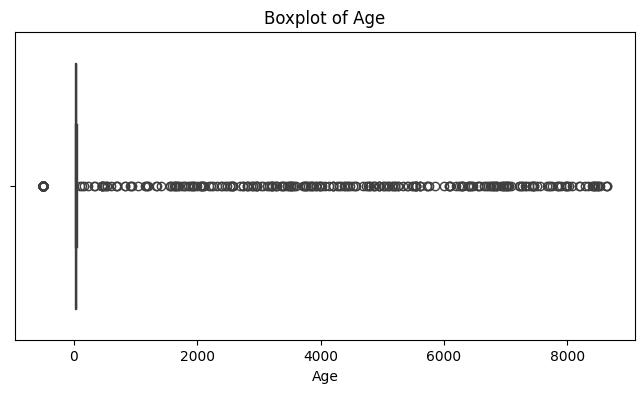


--- Checking column: Occupation ---
count    13685.000000
mean         7.558422
std          4.603693
min          0.000000
25%          4.000000
50%          8.000000
75%         12.000000
max         16.000000
Name: Occupation, dtype: float64
Number of outliers in 'Occupation': 0


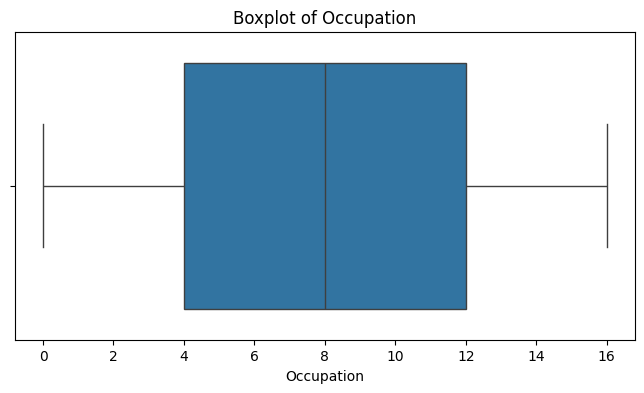


--- Checking column: Annual_Income ---
count    1.368500e+04
mean     1.423184e+05
std      1.180490e+06
min      7.006520e+03
25%      2.023580e+04
50%      3.806068e+04
75%      7.162520e+04
max      2.413726e+07
Name: Annual_Income, dtype: float64
Number of outliers in 'Annual_Income': 387


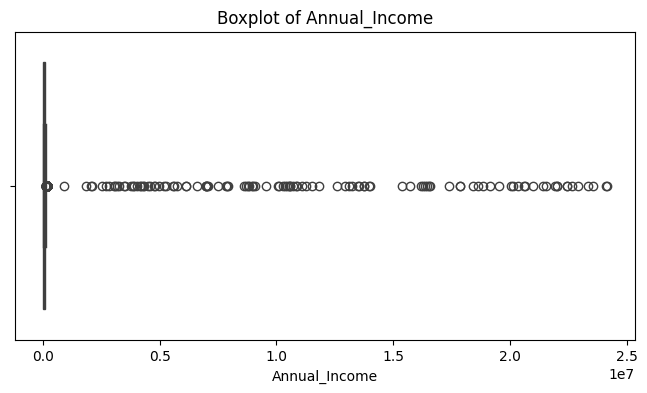


--- Checking column: Monthly_Inhand_Salary ---
count    13685.000000
mean      4098.885083
std       3000.300865
min        333.596667
25%       1824.843333
50%       3143.796667
75%       5556.570000
max      14866.446667
Name: Monthly_Inhand_Salary, dtype: float64
Number of outliers in 'Monthly_Inhand_Salary': 524


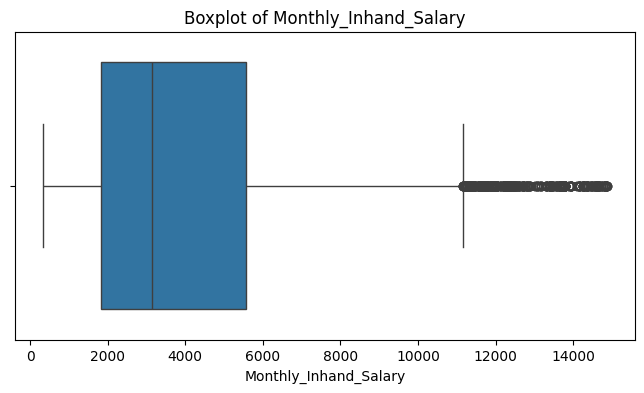


--- Checking column: Num_Bank_Accounts ---
count    13684.000000
mean        16.162672
std        111.236393
min          0.000000
25%          3.000000
50%          6.000000
75%          7.000000
max       1769.000000
Name: Num_Bank_Accounts, dtype: float64
Number of outliers in 'Num_Bank_Accounts': 169


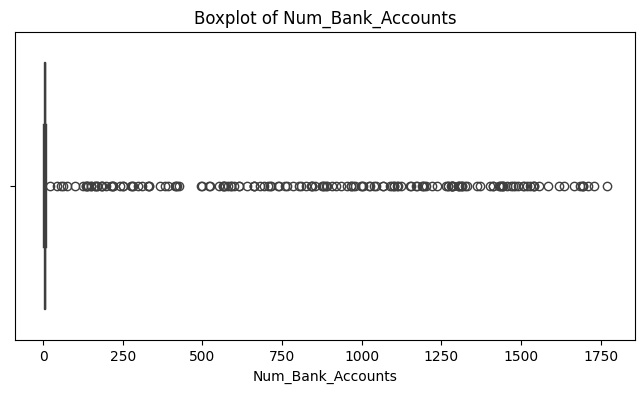


--- Checking column: Num_Credit_Card ---
count    13684.000000
mean        23.713315
std        131.924455
min          0.000000
25%          4.000000
50%          6.000000
75%          7.000000
max       1499.000000
Name: Num_Credit_Card, dtype: float64
Number of outliers in 'Num_Credit_Card': 347


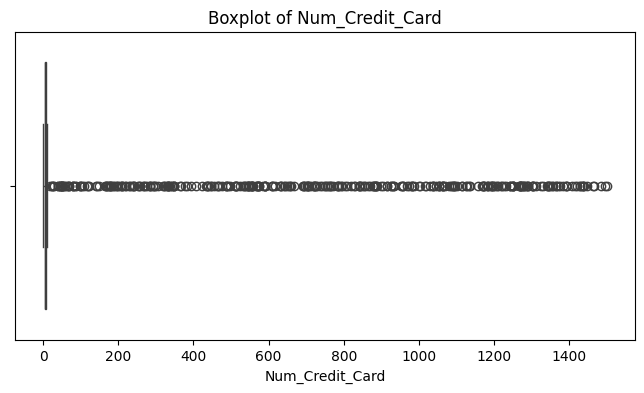


--- Checking column: Interest_Rate ---
count    13684.000000
mean        65.859836
std        437.410829
min          1.000000
25%          7.000000
50%         13.000000
75%         20.000000
max       5799.000000
Name: Interest_Rate, dtype: float64
Number of outliers in 'Interest_Rate': 256


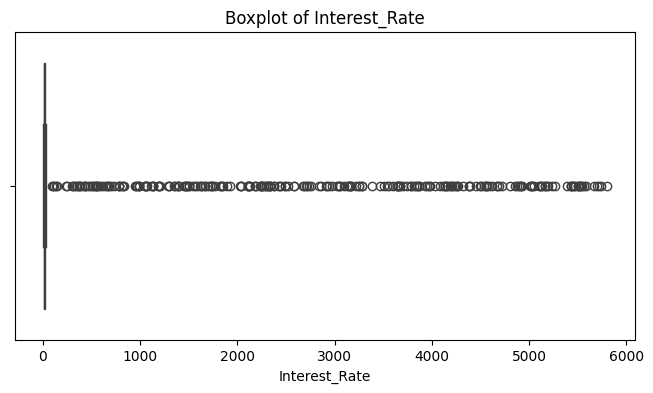


--- Checking column: Num_of_Loan ---
count    13685.000000
mean         3.359956
std         63.028031
min       -100.000000
25%          2.000000
50%          3.000000
75%          5.000000
max       1470.000000
Name: Num_of_Loan, dtype: float64
Number of outliers in 'Num_of_Loan': 580


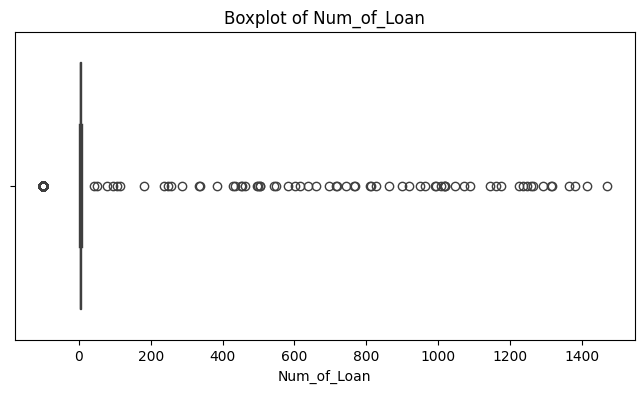


--- Checking column: Delay_from_due_date ---
count    13684.000000
mean        20.944315
std         14.619822
min         -5.000000
25%         10.000000
50%         18.000000
75%         28.000000
max         67.000000
Name: Delay_from_due_date, dtype: float64
Number of outliers in 'Delay_from_due_date': 489


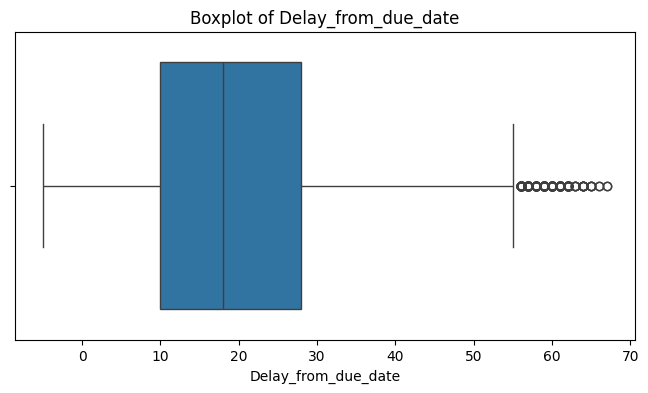


--- Checking column: Num_of_Delayed_Payment ---
count    13685.000000
mean        30.022872
std        216.912816
min         -3.000000
25%          9.000000
50%         14.000000
75%         18.000000
max       4343.000000
Name: Num_of_Delayed_Payment, dtype: float64
Number of outliers in 'Num_of_Delayed_Payment': 112


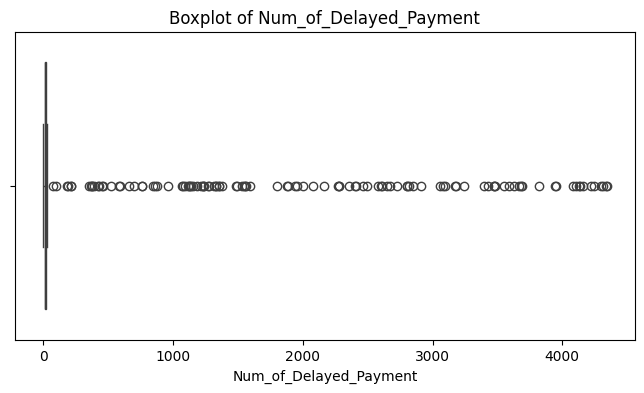


--- Checking column: Changed_Credit_Limit ---
count    13685.000000
mean        10.205417
std          6.661537
min         -6.450000
25%          5.310000
50%          9.210000
75%         14.290000
max         35.970000
Name: Changed_Credit_Limit, dtype: float64
Number of outliers in 'Changed_Credit_Limit': 216


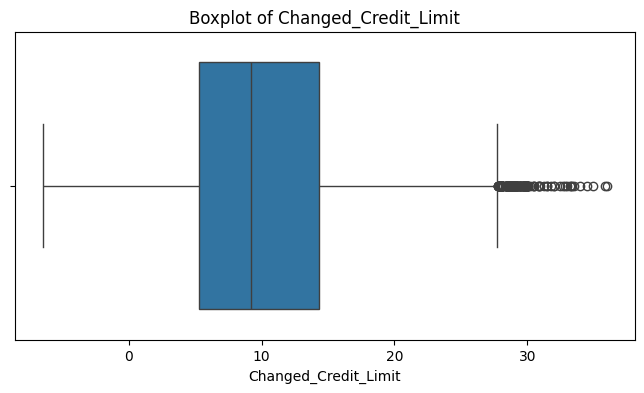


--- Checking column: Num_Credit_Inquiries ---
count    13685.000000
mean        32.137231
std        205.912041
min          0.000000
25%          4.000000
50%          7.000000
75%         10.000000
max       2593.000000
Name: Num_Credit_Inquiries, dtype: float64
Number of outliers in 'Num_Credit_Inquiries': 252


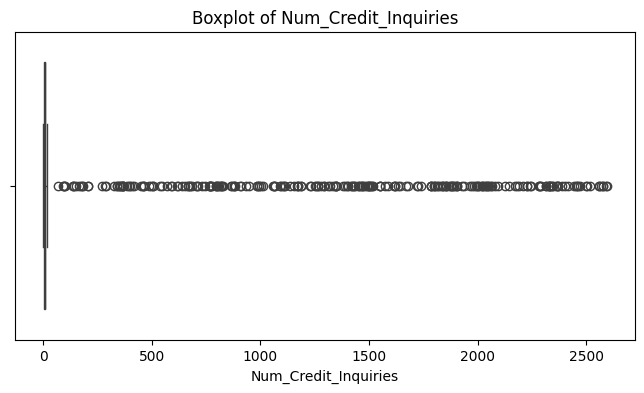


--- Checking column: Credit_Mix ---
count    13684.000000
mean         1.059120
std          0.658051
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          2.000000
Name: Credit_Mix, dtype: float64
Number of outliers in 'Credit_Mix': 5973


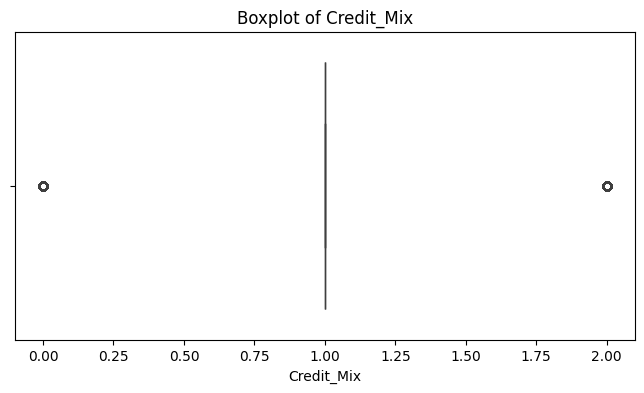


--- Checking column: Outstanding_Debt ---
count    13685.000000
mean      1396.035175
std       1157.022167
min          1.230000
25%        542.720000
50%       1127.260000
75%       1834.980000
max       4998.070000
Name: Outstanding_Debt, dtype: float64
Number of outliers in 'Outstanding_Debt': 909


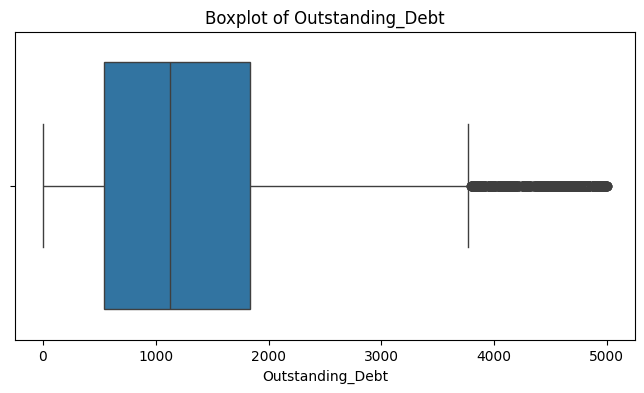


--- Checking column: Credit_Utilization_Ratio ---
count    13684.000000
mean        32.257224
std          5.101085
min         20.509652
25%         28.053177
50%         32.249585
75%         36.405840
max         48.540663
Name: Credit_Utilization_Ratio, dtype: float64
Number of outliers in 'Credit_Utilization_Ratio': 0


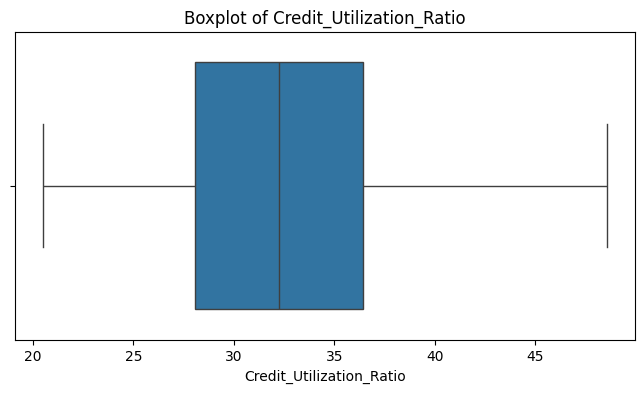


--- Checking column: Credit_History_Age ---
count    13685.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: Credit_History_Age, dtype: float64
Number of outliers in 'Credit_History_Age': 0


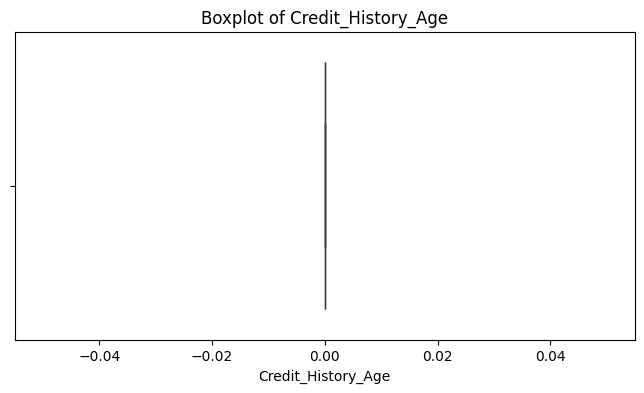


--- Checking column: Payment_of_Min_Amount ---
count    13685.00000
mean         1.40570
std          0.68982
min          0.00000
25%          1.00000
50%          2.00000
75%          2.00000
max          3.00000
Name: Payment_of_Min_Amount, dtype: float64
Number of outliers in 'Payment_of_Min_Amount': 0


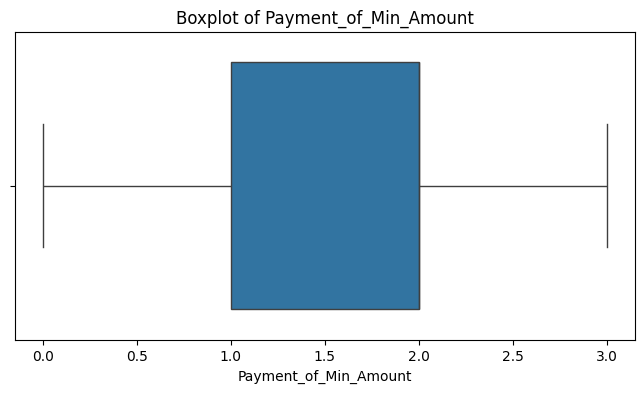


--- Checking column: Total_EMI_per_month ---
count    13684.000000
mean      1478.366736
std       8542.801982
min          0.000000
25%         31.779454
50%         74.869250
75%        179.280882
max      82347.000000
Name: Total_EMI_per_month, dtype: float64
Number of outliers in 'Total_EMI_per_month': 1069


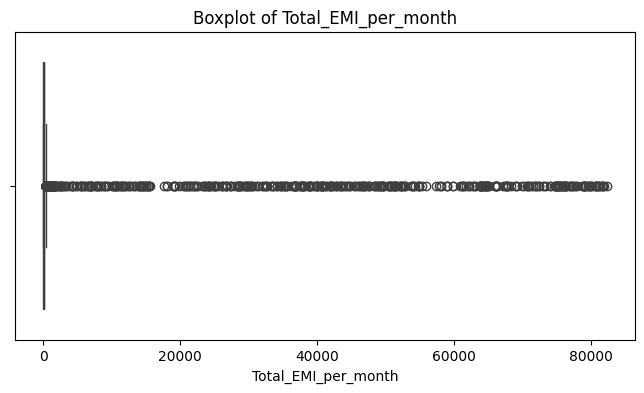


--- Checking column: Amount_invested_monthly ---
count    13685.000000
mean       191.820279
std        192.463222
min          0.000000
25%         77.017147
50%        130.527359
75%        223.299456
max       1801.358200
Name: Amount_invested_monthly, dtype: float64
Number of outliers in 'Amount_invested_monthly': 1302


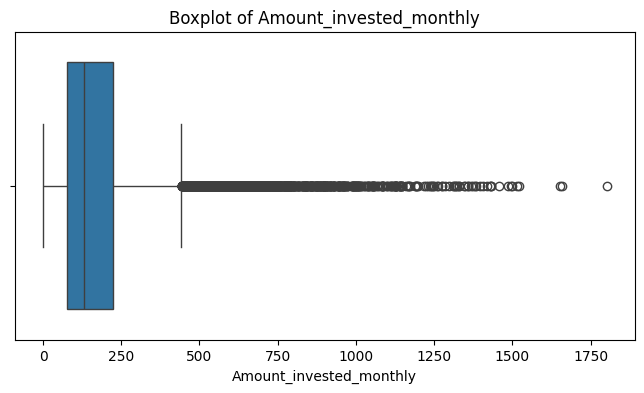


--- Checking column: Payment_Behaviour ---
count    13685.000000
mean         2.106248
std          1.877876
min          0.000000
25%          0.000000
50%          2.000000
75%          4.000000
max          5.000000
Name: Payment_Behaviour, dtype: float64
Number of outliers in 'Payment_Behaviour': 0


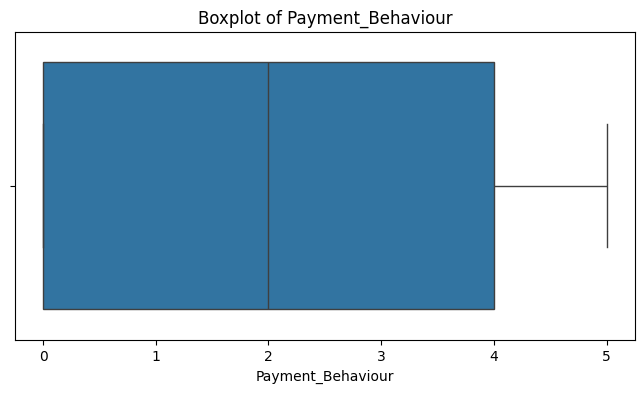


--- Checking column: Monthly_Balance ---
count    13685.000000
mean       404.828351
std        213.688675
min          0.103402
25%        272.756619
50%        338.308062
75%        468.927542
max       1566.125572
Name: Monthly_Balance, dtype: float64
Number of outliers in 'Monthly_Balance': 1139


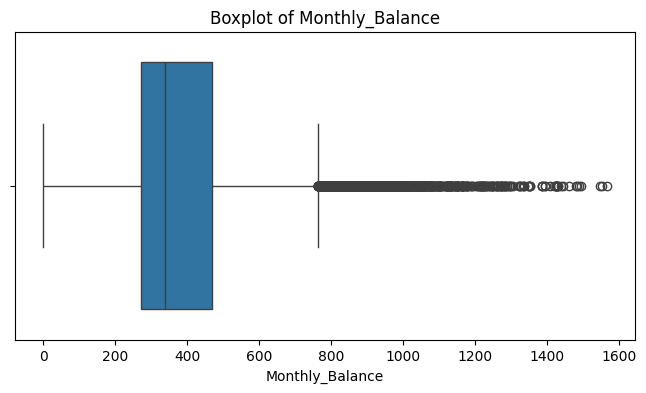


--- Checking column: Occupation_missing ---
count    13685.000000
mean         0.070369
std          0.255777
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Occupation_missing, dtype: float64
Number of outliers in 'Occupation_missing': 963


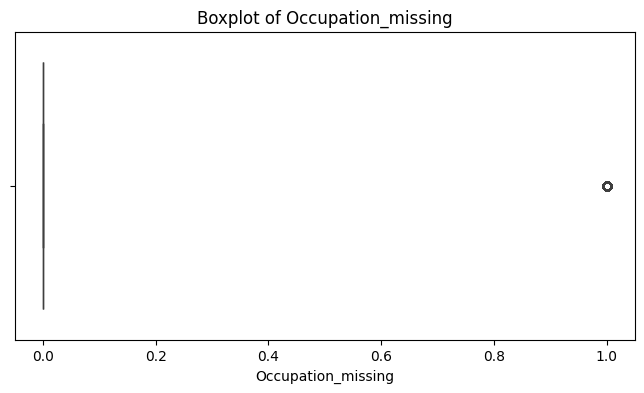


--- Checking column: Auto Loan ---
count    13685.000000
mean         0.299014
std          0.457842
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Auto Loan, dtype: float64
Number of outliers in 'Auto Loan': 0


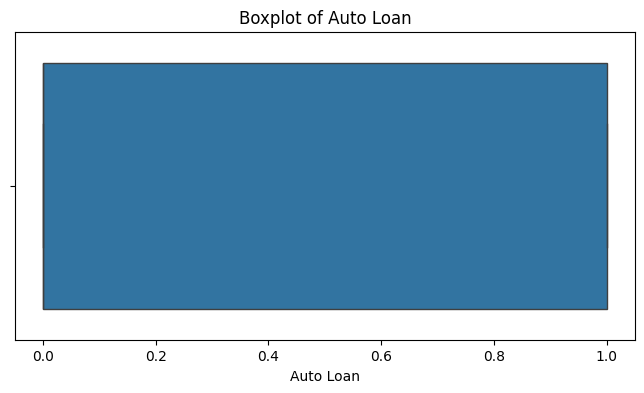


--- Checking column: Credit-Builder Loan ---
count    13685.000000
mean         0.316843
std          0.465263
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Credit-Builder Loan, dtype: float64
Number of outliers in 'Credit-Builder Loan': 0


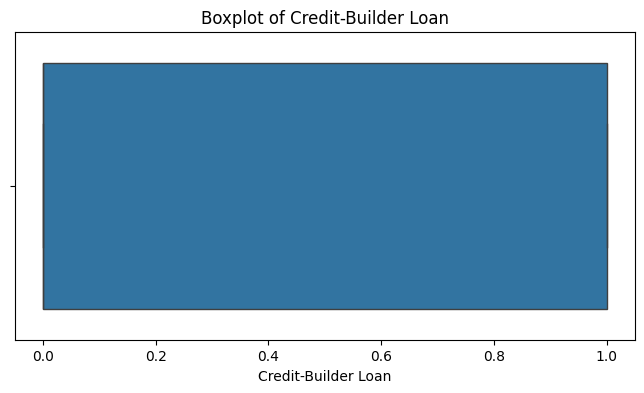


--- Checking column: Debt Consolidation Loan ---
count    13685.000000
mean         0.301644
std          0.458988
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Debt Consolidation Loan, dtype: float64
Number of outliers in 'Debt Consolidation Loan': 0


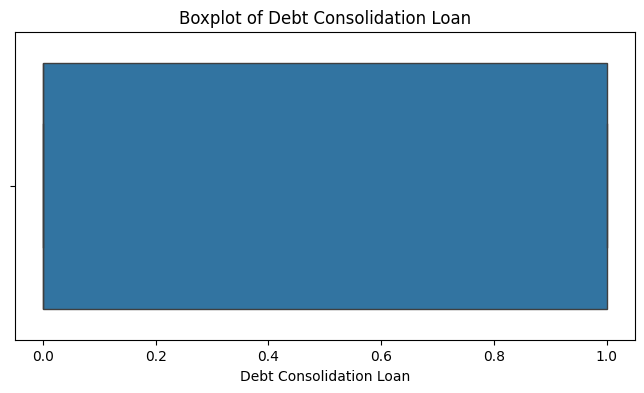


--- Checking column: Home Equity Loan ---
count    13685.000000
mean         0.314213
std          0.464218
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Home Equity Loan, dtype: float64
Number of outliers in 'Home Equity Loan': 0


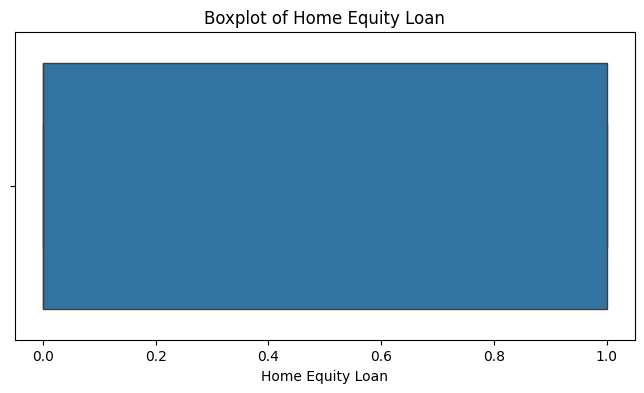


--- Checking column: Mortgage Loan ---
count    13685.000000
mean         0.312751
std          0.463631
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Mortgage Loan, dtype: float64
Number of outliers in 'Mortgage Loan': 0


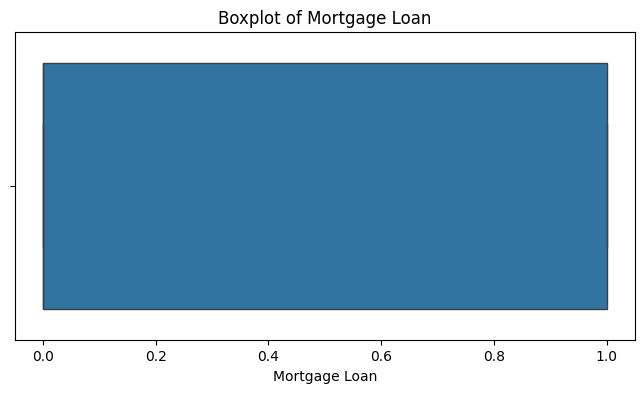


--- Checking column: Not Specified ---
count    13685.000000
mean         0.420972
std          0.493733
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Not Specified, dtype: float64
Number of outliers in 'Not Specified': 0


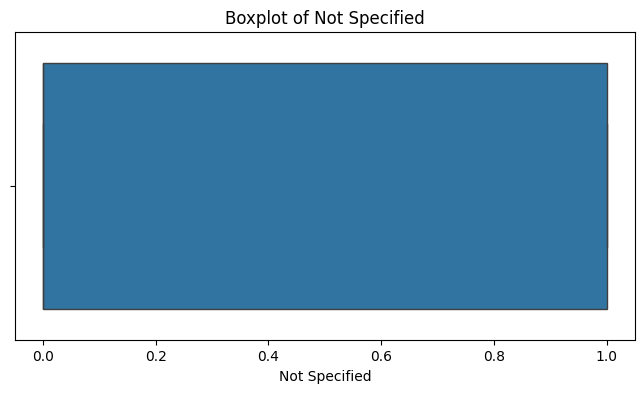


--- Checking column: Payday Loan ---
count    13685.000000
mean         0.321520
std          0.467077
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Payday Loan, dtype: float64
Number of outliers in 'Payday Loan': 0


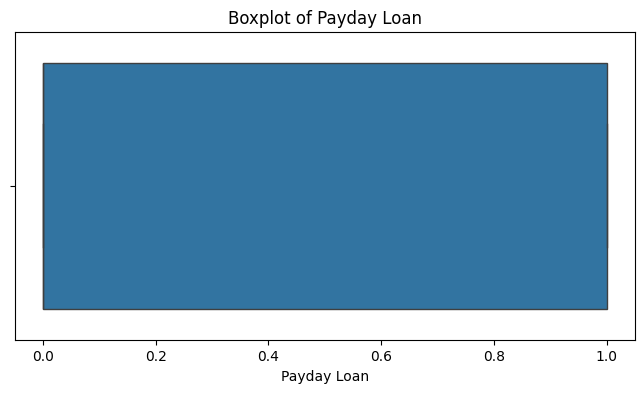


--- Checking column: Personal Loan ---
count    13685.000000
mean         0.322104
std          0.467300
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Personal Loan, dtype: float64
Number of outliers in 'Personal Loan': 0


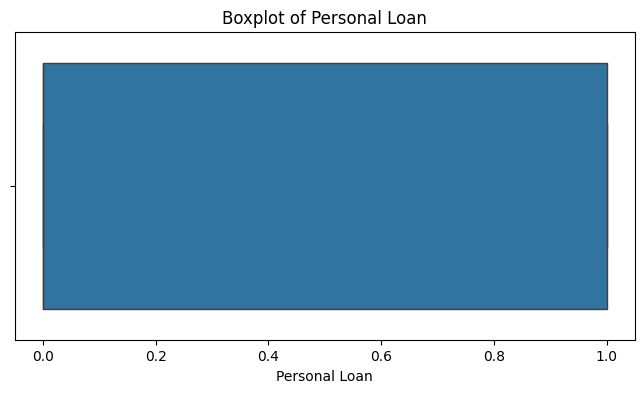


--- Checking column: Student Loan ---
count    13685.000000
mean         0.323274
std          0.467743
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Student Loan, dtype: float64
Number of outliers in 'Student Loan': 0


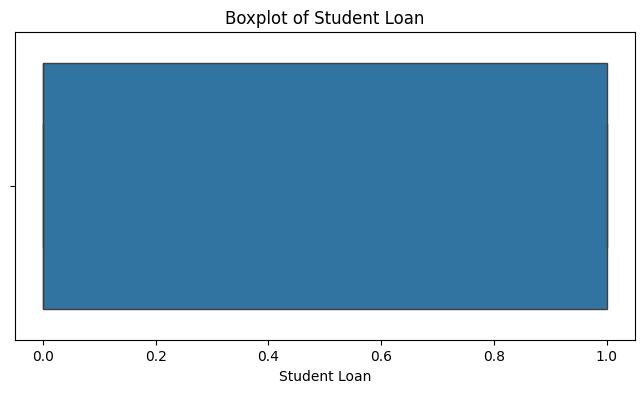

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

for col in df.select_dtypes(include=['float64', 'int64']).columns:
    print(f"\n--- Checking column: {col} ---")

    print(df[col].describe())

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = outliers.shape[0]
    print(f"Number of outliers in '{col}': {num_outliers}")

    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


In [45]:
min_values = df.min()
max_values = df.max()

summary = pd.DataFrame({'Min': min_values, 'Max': max_values})
print(summary)


                                  Min           Max
Age                       -500.000000  8.641000e+03
Occupation                   0.000000  1.600000e+01
Annual_Income             7006.520000  2.413726e+07
Monthly_Inhand_Salary      333.596667  1.486645e+04
Num_Bank_Accounts            0.000000  1.769000e+03
Num_Credit_Card              0.000000  1.499000e+03
Interest_Rate                1.000000  5.799000e+03
Num_of_Loan               -100.000000  1.470000e+03
Delay_from_due_date         -5.000000  6.700000e+01
Num_of_Delayed_Payment      -3.000000  4.343000e+03
Changed_Credit_Limit        -6.450000  3.597000e+01
Num_Credit_Inquiries         0.000000  2.593000e+03
Credit_Mix                   0.000000  2.000000e+00
Outstanding_Debt             1.230000  4.998070e+03
Credit_Utilization_Ratio    20.509652  4.854066e+01
Credit_History_Age           0.000000  0.000000e+00
Payment_of_Min_Amount        0.000000  3.000000e+00
Total_EMI_per_month          0.000000  8.234700e+04
Amount_inves

In [46]:
import numpy as np


continuous_cols = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary',
    'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate',
    'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
    'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt',
    'Credit_Utilization_Ratio', 'Total_EMI_per_month',
    'Amount_invested_monthly', 'Monthly_Balance'
]

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

    print(f"Column: {col} → Applied capping at {lower_bound:.2f} and {upper_bound:.2f}")

print("\n Outlier capping complete. Dataset shape remains:", df.shape)


Column: Age → Applied capping at -0.50 and 67.50
Column: Annual_Income → Applied capping at -56848.30 and 148709.30
Column: Monthly_Inhand_Salary → Applied capping at -3772.75 and 11154.16
Column: Num_Bank_Accounts → Applied capping at -3.00 and 13.00
Column: Num_Credit_Card → Applied capping at -0.50 and 11.50
Column: Interest_Rate → Applied capping at -12.50 and 39.50
Column: Num_of_Loan → Applied capping at -2.50 and 9.50
Column: Delay_from_due_date → Applied capping at -17.00 and 55.00
Column: Num_of_Delayed_Payment → Applied capping at -4.50 and 31.50
Column: Changed_Credit_Limit → Applied capping at -8.16 and 27.76
Column: Num_Credit_Inquiries → Applied capping at -5.00 and 19.00
Column: Outstanding_Debt → Applied capping at -1395.67 and 3773.37
Column: Credit_Utilization_Ratio → Applied capping at 15.52 and 48.93
Column: Total_EMI_per_month → Applied capping at -189.47 and 400.53
Column: Amount_invested_monthly → Applied capping at -142.41 and 442.72
Column: Monthly_Balance → Ap

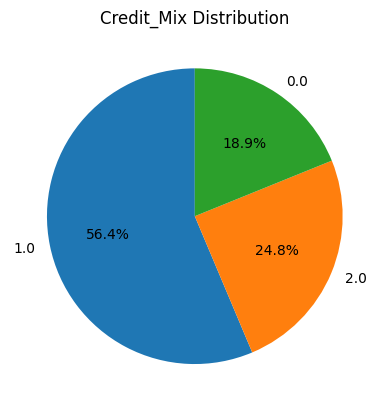

In [47]:
df['Credit_Mix'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Credit_Mix Distribution')
plt.ylabel('')
plt.show()


In [48]:
X = df.drop('Credit_Mix', axis=1)
y = df['Credit_Mix']


In [50]:
df['Credit_Mix']

,Credit_Mix
0,2.0
1,2.0
2,2.0
3,2.0
4,2.0
...,...
13680,1.0
13681,1.0
13682,1.0
13683,1.0


In [51]:
# Check for NaNs in y
print(y.isnull().sum())

1


In [52]:
y = y.fillna(y.mode()[0])

### Train-Test Split

We split the dataset into training and test sets using stratified sampling to maintain the class distribution across splits.


In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### Model Building

We train multiple classification models to predict credit score:
- Logistic Regression
- Random Forest
- XGBoost
- Gradient Boosting
- AdaBoost
- LightGBM
- CatBoost


### Model Evaluation

We evaluate models using accuracy, precision, recall, and F1-score, and compare their performance to identify the best-performing approach.



Model: Logistic Regression


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.7135549872122762
Classification Report:
               precision    recall  f1-score   support

         0.0       0.72      0.66      0.69       516
         1.0       0.71      0.82      0.76      1543
         2.0       0.70      0.51      0.59       678

    accuracy                           0.71      2737
   macro avg       0.71      0.66      0.68      2737
weighted avg       0.71      0.71      0.71      2737

Confusion Matrix:
 [[ 338  178    0]
 [ 128 1267  148]
 [   1  329  348]]


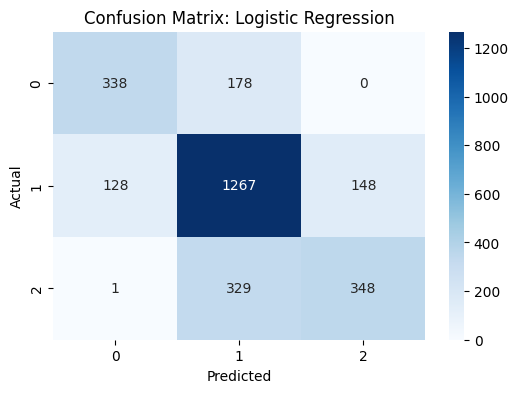

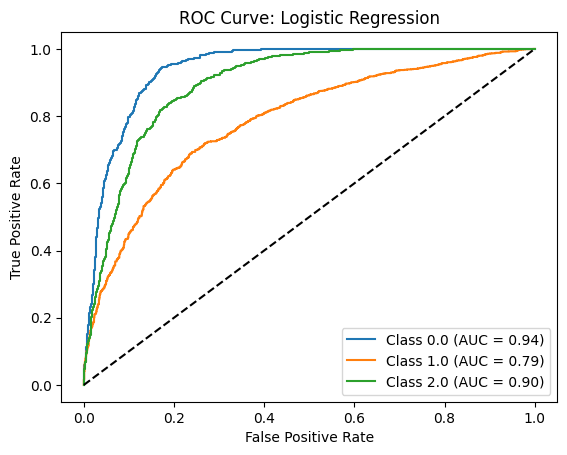


Model: Random Forest
Accuracy: 0.8545853123858239
Classification Report:
               precision    recall  f1-score   support

         0.0       0.78      0.92      0.85       516
         1.0       0.93      0.80      0.86      1543
         2.0       0.78      0.92      0.85       678

    accuracy                           0.85      2737
   macro avg       0.83      0.88      0.85      2737
weighted avg       0.87      0.85      0.86      2737

Confusion Matrix:
 [[ 476   40    0]
 [ 131 1240  172]
 [   0   55  623]]


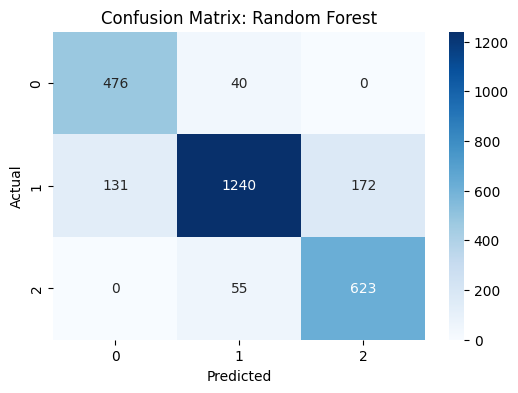

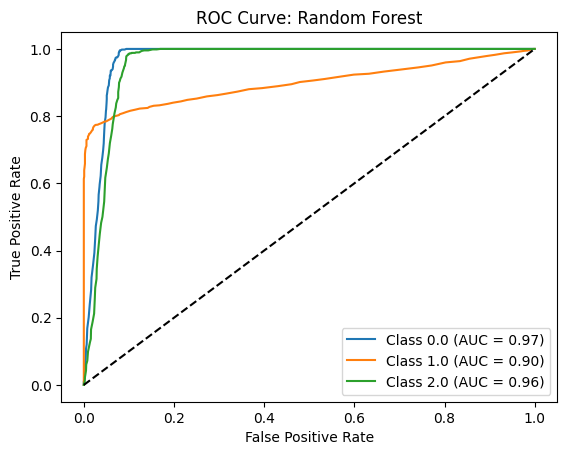


Model: XGBoost


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:19:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.8381439532334674
Classification Report:
               precision    recall  f1-score   support

         0.0       0.77      0.91      0.84       516
         1.0       0.91      0.79      0.85      1543
         2.0       0.77      0.88      0.82       678

    accuracy                           0.84      2737
   macro avg       0.82      0.86      0.84      2737
weighted avg       0.85      0.84      0.84      2737

Confusion Matrix:
 [[ 471   45    0]
 [ 139 1225  179]
 [   0   80  598]]


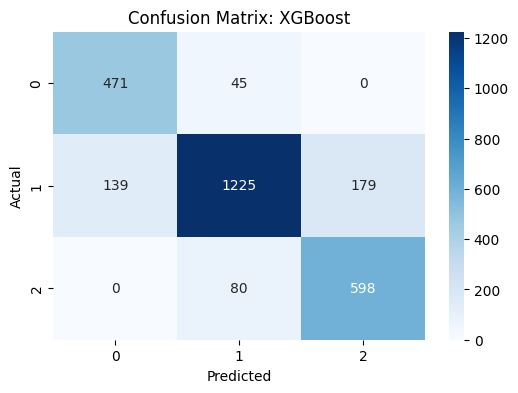

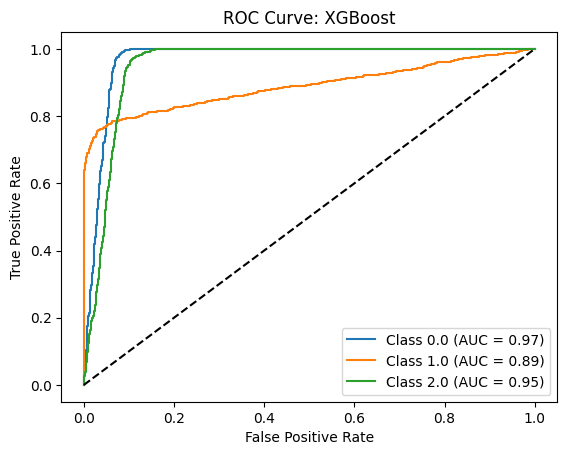


Model: Gradient Boosting
Accuracy: 0.8399707709170625
Classification Report:
               precision    recall  f1-score   support

         0.0       0.77      0.90      0.83       516
         1.0       0.91      0.79      0.85      1543
         2.0       0.77      0.90      0.83       678

    accuracy                           0.84      2737
   macro avg       0.82      0.86      0.84      2737
weighted avg       0.85      0.84      0.84      2737

Confusion Matrix:
 [[ 464   52    0]
 [ 138 1226  179]
 [   0   69  609]]


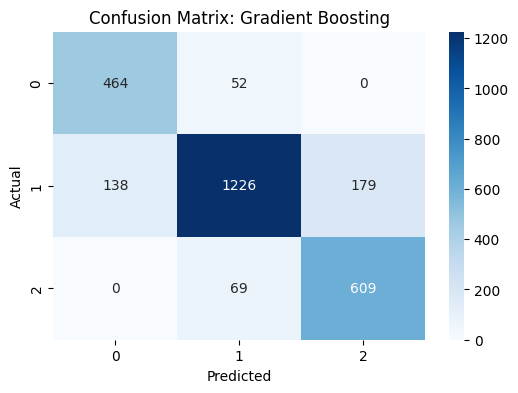

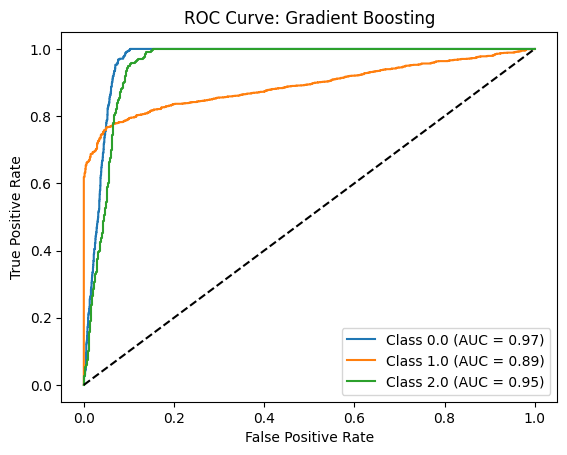


Model: AdaBoost
Accuracy: 0.7541103397880892
Classification Report:
               precision    recall  f1-score   support

         0.0       0.71      0.64      0.68       516
         1.0       0.78      0.79      0.78      1543
         2.0       0.73      0.76      0.74       678

    accuracy                           0.75      2737
   macro avg       0.74      0.73      0.73      2737
weighted avg       0.75      0.75      0.75      2737

Confusion Matrix:
 [[ 332  184    0]
 [ 134 1214  195]
 [   0  160  518]]


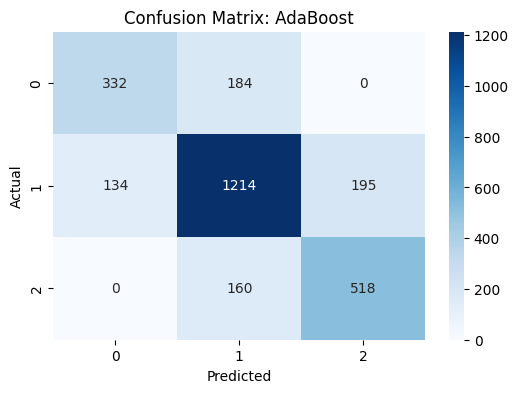

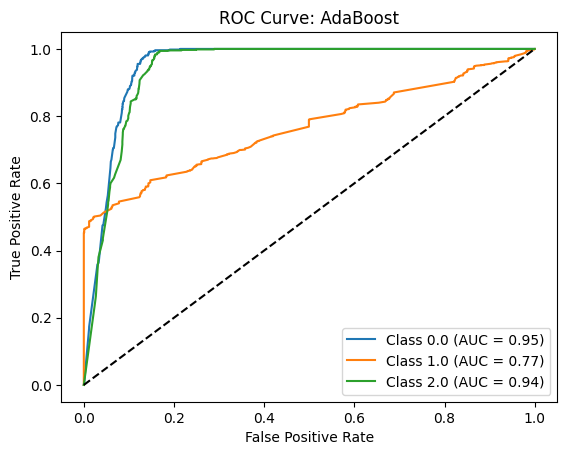


Model: LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003063 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2313
[LightGBM] [Info] Number of data points in the train set: 10948, number of used features: 29
[LightGBM] [Info] Start training from score -1.667542
[LightGBM] [Info] Start training from score -0.573620
[LightGBM] [Info] Start training from score -1.395102


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Accuracy: 0.8410668615272195
Classification Report:
               precision    recall  f1-score   support

         0.0       0.77      0.91      0.83       516
         1.0       0.92      0.78      0.85      1543
         2.0       0.76      0.92      0.83       678

    accuracy                           0.84      2737
   macro avg       0.82      0.87      0.84      2737
weighted avg       0.85      0.84      0.84      2737

Confusion Matrix:
 [[ 472   44    0]
 [ 143 1208  192]
 [   0   56  622]]


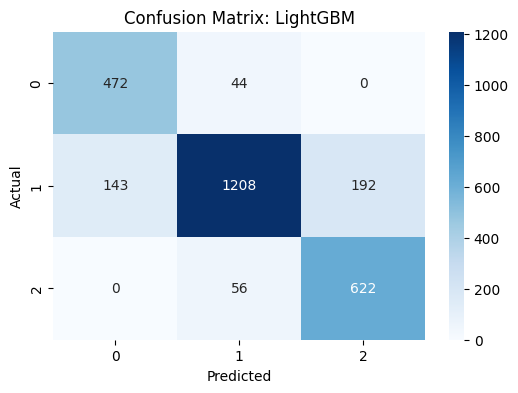

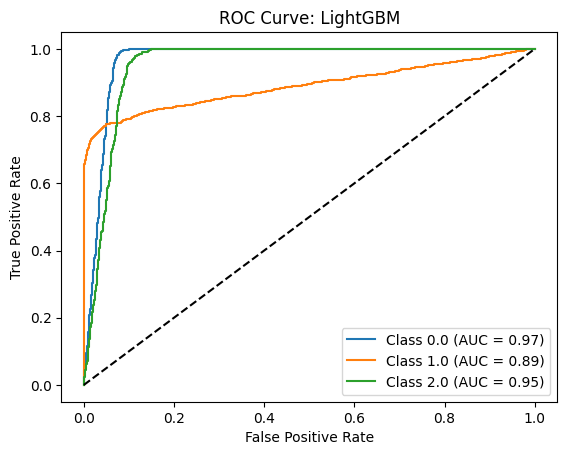


Model: CatBoost
Accuracy: 0.8385093167701864
Classification Report:
               precision    recall  f1-score   support

         0.0       0.77      0.91      0.83       516
         1.0       0.91      0.79      0.85      1543
         2.0       0.77      0.89      0.83       678

    accuracy                           0.84      2737
   macro avg       0.82      0.86      0.84      2737
weighted avg       0.85      0.84      0.84      2737

Confusion Matrix:
 [[ 468   48    0]
 [ 141 1225  177]
 [   0   76  602]]


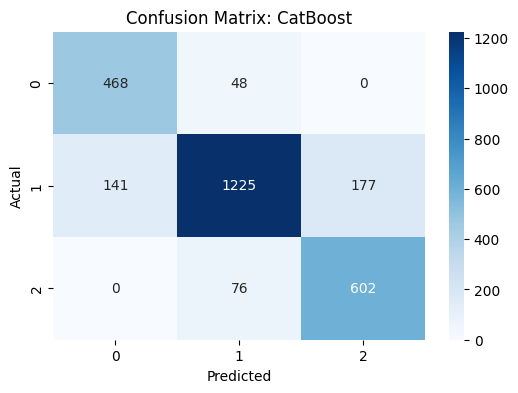

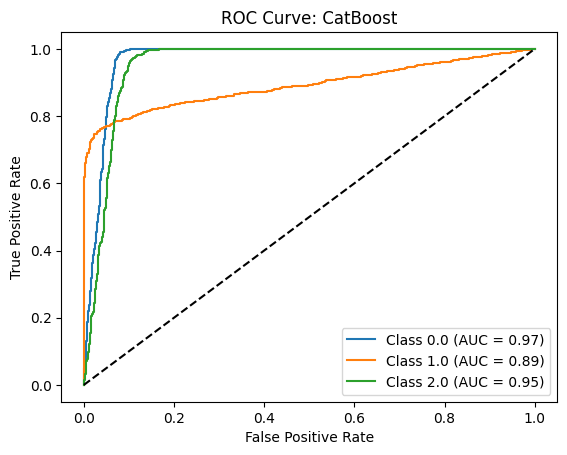

In [59]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ✅ Create model dictionary
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'LightGBM': LGBMClassifier(),
    'CatBoost': CatBoostClassifier(verbose=0)
}

# ✅ Handle missing values in X_train, X_test
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# ✅ Binarize y_test for multiclass ROC
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)

# ✅ Loop over models
for name, model in models.items():
    print(f"\nModel: {name}")

    # Train
    model.fit(X_train_imputed, y_train)

    # Predict
    y_pred = model.predict(X_test_imputed)
    y_proba = model.predict_proba(X_test_imputed)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)
    print("Classification Report:\n", classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

    # ✅ Confusion Matrix plot
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # ✅ ROC curves and AUC
    fpr, tpr, roc_auc = dict(), dict(), dict()
    for i, cls in enumerate(classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure()
    for i, cls in enumerate(classes):
        plt.plot(fpr[i], tpr[i], label=f'Class {cls} (AUC = {roc_auc[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve: {name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()


### Hyperparameter Tuning

We apply GridSearchCV to tune Random Forest with a parameter grid:
- n_estimators: [100, 200]
- max_depth: [5, 10]
- min_samples_split: [2, 5]

We then re-evaluate the tuned model to check performance improvements.


In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\n Best Parameters found for Random Forest:")
print(grid.best_params_)

best_rf = grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("\n Random Forest Performance after Tuning:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))



 Best Parameters found for Random Forest:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

 Random Forest Performance after Tuning:
Accuracy: 0.8443551333576909
Classification Report:
               precision    recall  f1-score   support

         0.0       0.76      0.93      0.84       516
         1.0       0.92      0.79      0.85      1543
         2.0       0.78      0.90      0.83       678

    accuracy                           0.84      2737
   macro avg       0.82      0.88      0.84      2737
weighted avg       0.86      0.84      0.84      2737

Confusion Matrix:
 [[ 482   34    0]
 [ 150 1217  176]
 [   0   66  612]]


In [56]:
import pandas as pd

data = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'Gradient Boosting', 'AdaBoost', 'LightGBM', 'CatBoost'],
    'Accuracy': [0.72, 0.86, 0.85, 0.84, 0.77, 0.85, 0.85],
    'Strengths': [
        'Fast, interpretable, good baseline',
        'Excellent accuracy, robust, strong recall',
        'High accuracy, handles imbalance',
        'Strong performance, balances precision/recall',
        'Decent on class 2, simple boosting',
        'Fast, scalable, good on class 0 and 2',
        'Great with categorical data, balanced performance'
    ],
    'Limitations': [
        'Weak on non-linear patterns, struggled on class 2',
        'Less interpretable, some misclassification on class 1',
        'Needs tuning, some complexity',
        'Slightly lower class 1 recall, tuning sensitive',
        'Lower accuracy, sensitive to noise',
        'Needs tuning, sensitive to data format',
        'Needs more RAM, slower on CPU'
    ]
}

df_results = pd.DataFrame(data)
df_results


,Model,Accuracy,Strengths,Limitations
0,Logistic Regression,0.72,"Fast, interpretable, good baseline","Weak on non-linear patterns, struggled on class 2"
1,Random Forest,0.86,"Excellent accuracy, robust, strong recall","Less interpretable, some misclassification on ..."
2,XGBoost,0.85,"High accuracy, handles imbalance","Needs tuning, some complexity"
3,Gradient Boosting,0.84,"Strong performance, balances precision/recall","Slightly lower class 1 recall, tuning sensitive"
4,AdaBoost,0.77,"Decent on class 2, simple boosting","Lower accuracy, sensitive to noise"
5,LightGBM,0.85,"Fast, scalable, good on class 0 and 2","Needs tuning, sensitive to data format"
6,CatBoost,0.85,"Great with categorical data, balanced performance","Needs more RAM, slower on CPU"


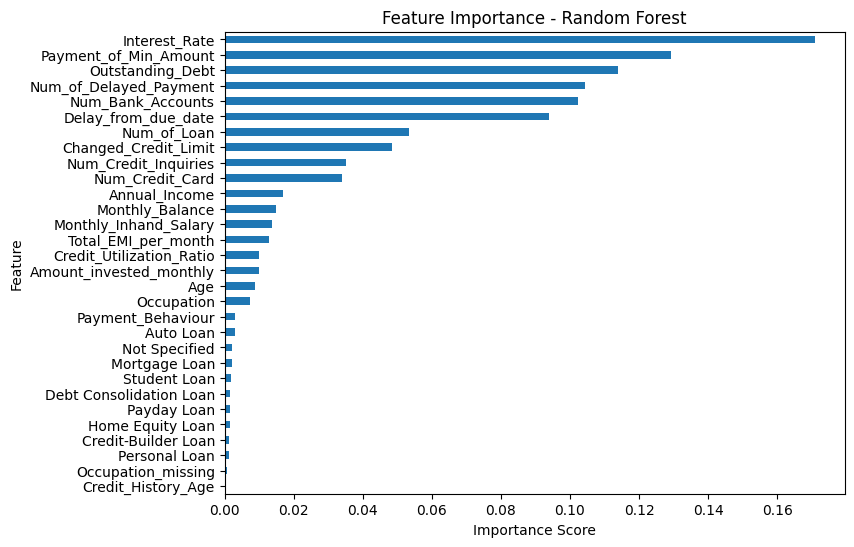

In [57]:
import pandas as pd
import matplotlib.pyplot as plt


importances = pd.Series(best_rf.feature_importances_, index=X.columns)


importances.sort_values(ascending=True).plot(kind='barh', figsize=(8, 6))
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()


### Model Interpretability with SHAP

We use SHAP to explain model predictions and visualize feature importance, identifying top drivers such as:
- Interest_Rate
- Payment_of_Min_Amount
- Outstanding_Debt

This helps increase transparency and trust in model decisions.


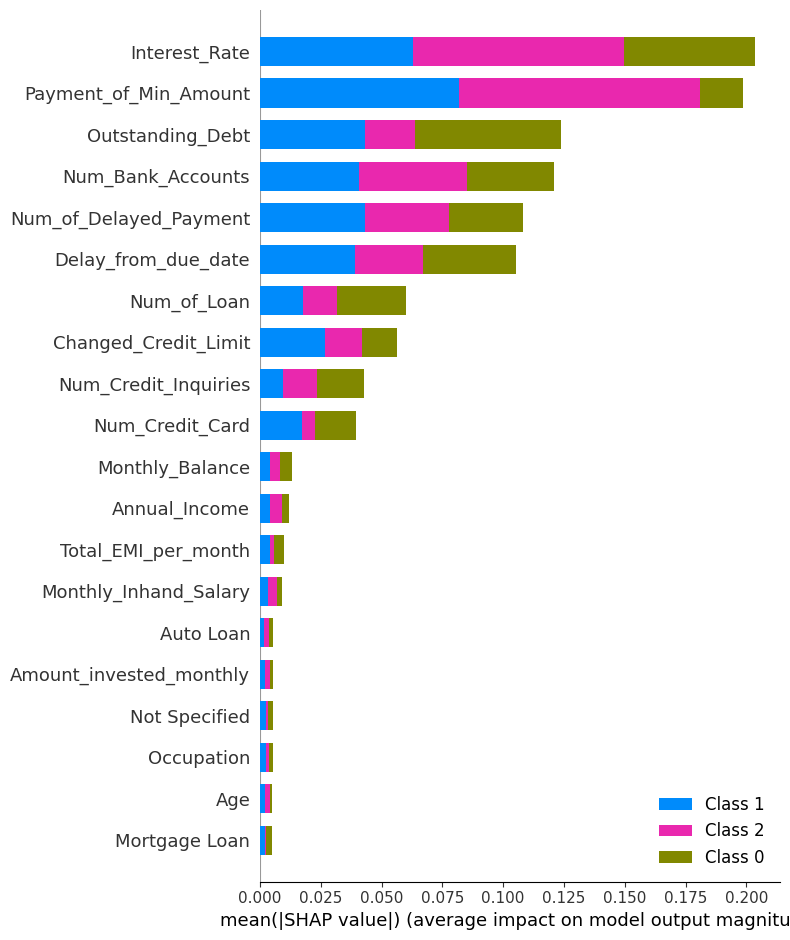

<Figure size 640x480 with 0 Axes>

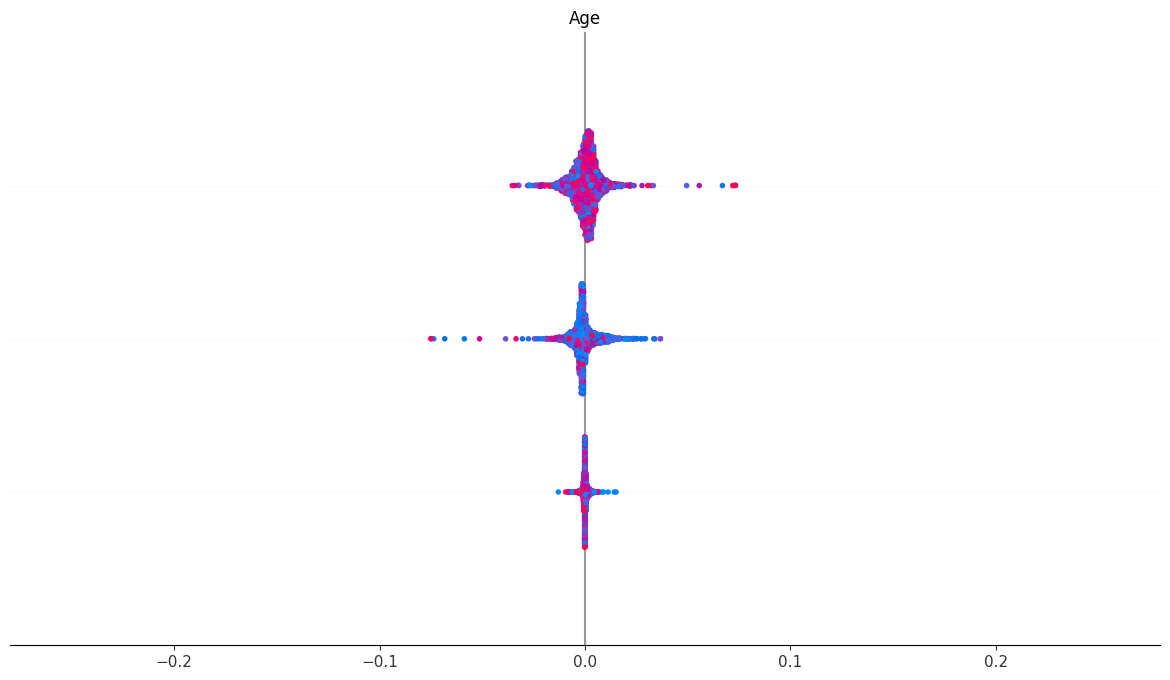

In [58]:
import shap


explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)


shap.summary_plot(shap_values, X_test, plot_type="bar")


shap.summary_plot(shap_values, X_test)
